In [2]:
!pip install scikit-posthocs

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 2.8 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/9.5 MB 2.2 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.5 MB 2.2 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.5 MB 2.3 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.5 MB 2.2 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.5 MB 2.1 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.5 MB 1.9 MB/s eta 0:00:04
   ------------- -------------------------- 3.1/9.5 MB 1.9 MB/s eta 0:00:04
   --------------- ------------------------ 3.7/9.5 MB 2.0 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.5 MB 2.0 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.5 MB 2.0 MB/s eta 0:00:03
   --------------

In [ ]:
import pandas as pd
import numpy as np

# accuracy values and their confidence intervals for each model

data = pd.DataFrame({

"ExtraTrees":[
0.9048-0.0138,
0.9048,
0.9048+0.0138
],

"LogisticRegression":[
0.9967-0.0002,
0.9967,
0.9967+0.0002
],

"RandomForest":[
0.9999-0.000008,
0.9999,
0.9999+0.000008
],

"XGBoost":[
0.9977-0.0001,
0.9977,
0.9977+0.0001
]

})

print(data)

   ExtraTrees  LogisticRegression  RandomForest  XGBoost
0      0.8910              0.9965      0.999892   0.9976
1      0.9048              0.9967      0.999900   0.9977
2      0.9186              0.9969      0.999908   0.9978


In [4]:
from scipy.stats import friedmanchisquare

stat, p = friedmanchisquare(
data["ExtraTrees"],
data["LogisticRegression"],
data["RandomForest"],
data["XGBoost"]
)

print("Friedman Statistic:", stat)
print("p-value:", p)

Friedman Statistic: 9.0
p-value: 0.02929088653488826


In [42]:
import scikit_posthocs as sp

nemenyi = sp.posthoc_nemenyi_friedman(data)

print(nemenyi)

                    ExtraTrees  LogisticRegression  RandomForest   XGBoost
ExtraTrees            1.000000            0.778483      0.022956  0.229104
LogisticRegression    0.778483            1.000000      0.229104  0.778483
RandomForest          0.022956            0.229104      1.000000  0.778483
XGBoost               0.229104            0.778483      0.778483  1.000000


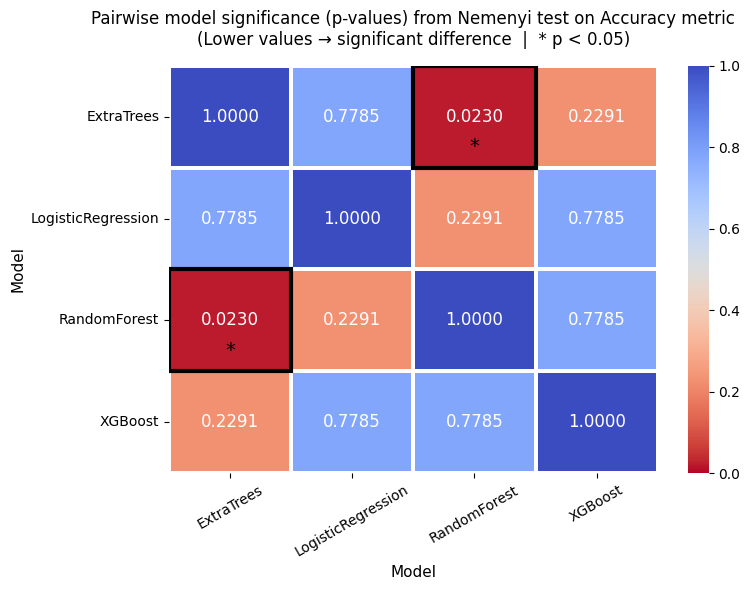

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

# Mask diagonal for cleaner styling
mask = np.eye(len(nemenyi), dtype=bool)

sns.heatmap(
    nemenyi,
    annot=True,
    fmt=".4f",
    cmap="coolwarm_r",
    vmin=0, vmax=1,
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 12},
    ax=ax
)

# Highlight significant cells (p < 0.05) with a border
for i in range(len(nemenyi)):
    for j in range(len(nemenyi.columns)):
        if i != j and nemenyi.iloc[i, j] < 0.05:
            ax.add_patch(plt.Rectangle((j, i), 1, 1,
                         fill=False, edgecolor='black',
                         lw=3, zorder=5))
            ax.text(j + 0.5, i + 0.85, '*', ha='center',
                    fontsize=14, color='black', zorder=6)

ax.set_title(
    "Pairwise model significance (p-values) from Nemenyi test on Accuracy metric\n"
    "(Lower values → significant difference  |  * p < 0.05)",
    fontsize=12, pad=15
)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
# plt.savefig('nemenyi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

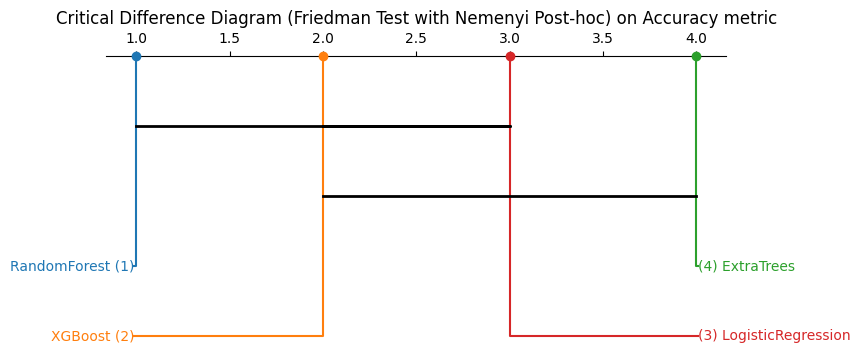

In [49]:
import scikit_posthocs as sp
import matplotlib.pyplot as plt

# Calculate average ranks
avg_ranks = data.rank(axis=1, ascending=False).mean()

# Plot Critical Difference Diagram
plt.figure(figsize=(8,4))

sp.critical_difference_diagram(
    avg_ranks,
    nemenyi
)

plt.title("Critical Difference Diagram (Friedman Test with Nemenyi Post-hoc) on Accuracy metric", fontsize=12)

plt.show()